Computing numerical solution...
Numerical solution computed.

--- Training PIKAN (efficientkan) ---
[efficient] Epoch    0, Loss: 3.078358
[efficient] Epoch  500, Loss: 0.000476
[efficient] Epoch 1000, Loss: 0.000132
[efficient] Epoch 1500, Loss: 0.000088
[efficient] Epoch 2000, Loss: 0.000074
[efficient] Epoch 2500, Loss: 0.000079
[efficient] Epoch 3000, Loss: 0.000121
[efficient] Epoch 3500, Loss: 0.000080
[efficient] Epoch 4000, Loss: 0.000092
[efficient] Epoch 4500, Loss: 0.000099
[efficient] Training finished in 317.40s, Final Loss: 0.000102

--- Training LMKAN ---
[lmkan] Epoch    0, Loss: 1.596920
[lmkan] Epoch  500, Loss: 0.001764
[lmkan] Epoch 1000, Loss: 0.000258
[lmkan] Epoch 1500, Loss: 0.000136
[lmkan] Epoch 2000, Loss: 0.000106
[lmkan] Epoch 2500, Loss: 0.000119
[lmkan] Epoch 3000, Loss: 0.000067
[lmkan] Epoch 3500, Loss: 0.000095
[lmkan] Epoch 4000, Loss: 0.000116
[lmkan] Epoch 4500, Loss: 0.000103
[lmkan] Training finished in 187.14s, Final Loss: 0.000117

--- Model Par

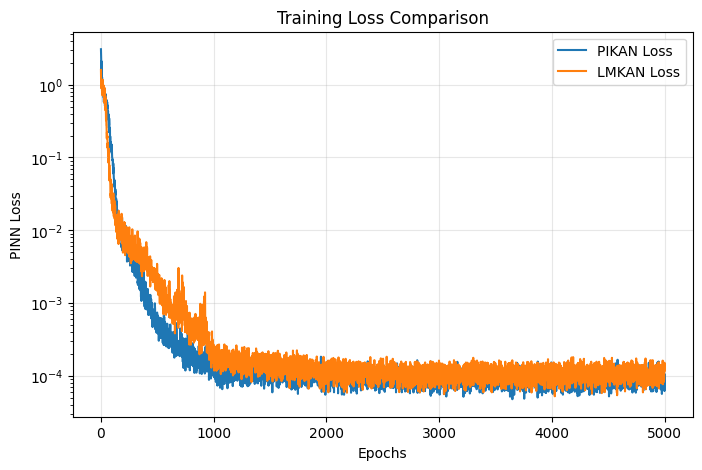

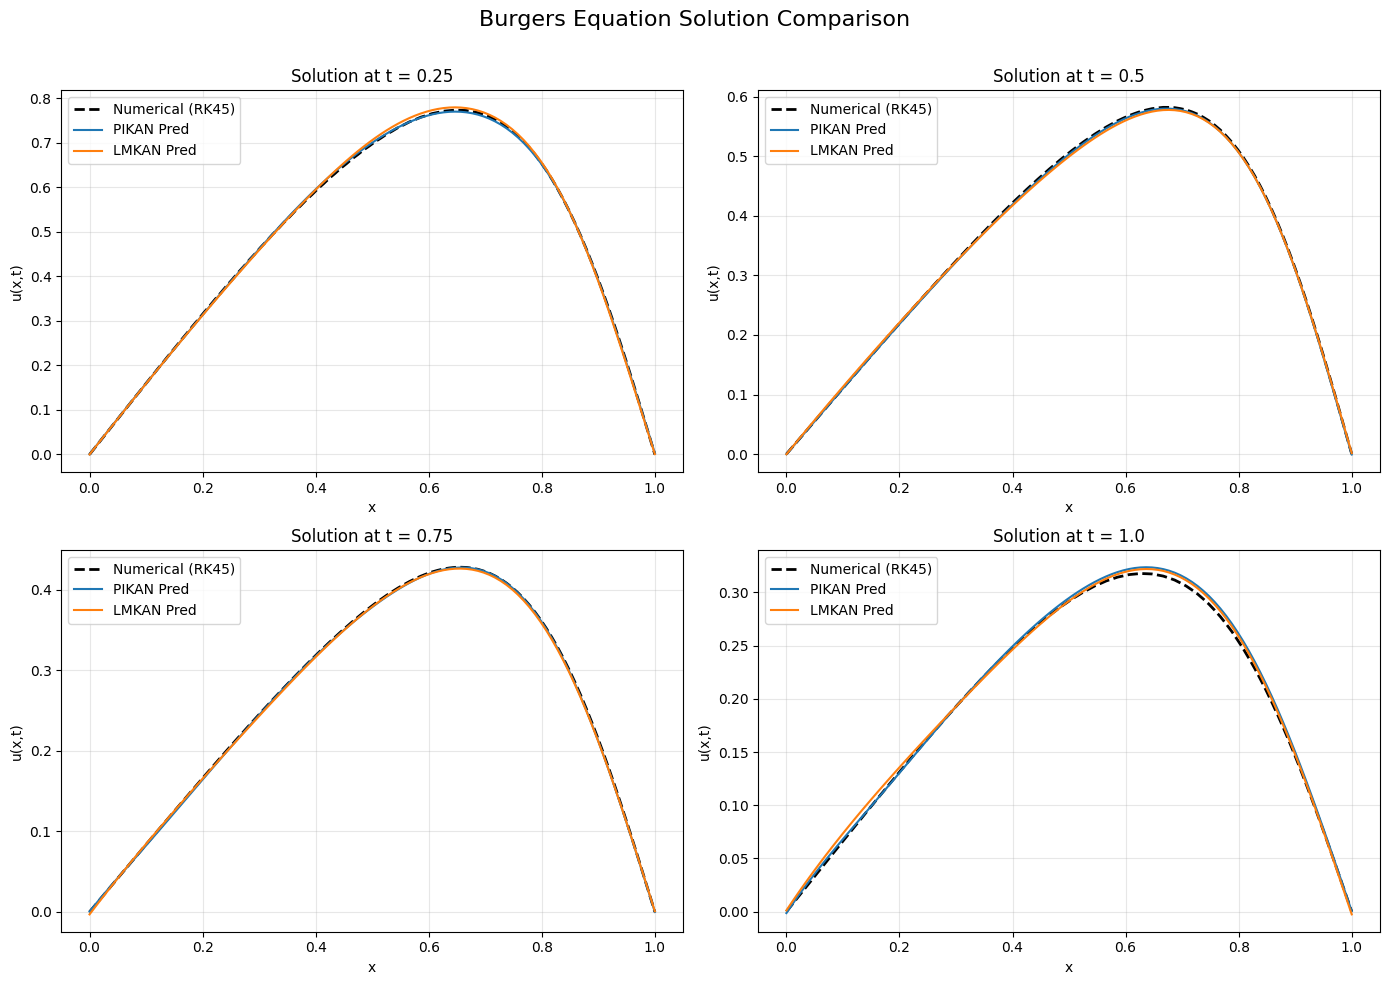

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib.colors import Normalize
import time
import os
import random

# ==========================================
# Set Fixed Random Seed for Reproducibility
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
set_seed(42)

# Import efficientkan and LMKAN
try:
    import efficientkan
    EFFICIENTKAN_AVAILABLE = True
except ImportError:
    print("Warning: efficientkan not found. PIKAN model will be skipped.")
    EFFICIENTKAN_AVAILABLE = False

try:
    import lm_kan
    LMKAN_AVAILABLE = True
except ImportError:
    print("Warning: lm_kan.py not found. Make sure it is in the same directory.")
    LMKAN_AVAILABLE = False

# ==========================================
# 1. Numerical Solution Setup
# ==========================================
print("Computing numerical solution...")
def burgers_rhs(t, u, dx, v):
    dudt = np.zeros_like(u)
    dudt[1:-1] = -u[1:-1] * (u[2:] - u[:-2]) / (2*dx) + v * (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    dudt[0] = 0  
    dudt[-1] = 0  
    return dudt

L = 1.0  
N_x = 100 
dx = L / (N_x - 1)  
v = 0.1 
x_np = np.linspace(0, L, N_x)
u0 = np.sin(np.pi * x_np)
t_span = (0, 1)
N_t = 100
t_eval = np.linspace(0, 1, N_t)  

solution = solve_ivp(burgers_rhs, t_span, u0, args=(dx, v), t_eval=t_eval, method='RK45')
print("Numerical solution computed.")

# ==========================================
# 2. Physics-Informed Training Setup
# ==========================================
# Time and space grids
x = torch.linspace(0, 1, N_x).view(-1, 1).requires_grad_(True)
t = torch.linspace(0.1, 1, N_t).view(-1, 1).requires_grad_(True)
x_ic = x.clone().detach().requires_grad_(True)
zeros = torch.zeros_like(t)
ones = torch.ones_like(t)

t_ic = torch.zeros_like(x_ic).requires_grad_(True)                        
u_ic = torch.sin(np.pi * x_ic)  

def get_pinn_loss(model, x, t, u_ic, model_type="efficient"):
    if model_type == "efficient":
        u_pred = model(x, t)
    else:
        u_pred = model(torch.cat([x, t], dim=1))
        
    t_sharp = np.linspace(0, 1, 100)
    num_points = int(len(t_sharp) * 0.1)
    # Note: drawing random points inside the loss step can create noisy loss curves 
    # but keeping it identical to the original implementation
    selected_points = np.random.choice(t_sharp, num_points, replace=False)
    
    u_t = torch.autograd.grad(u_pred, t, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_x = torch.autograd.grad(u_pred, x, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    
    f_pred = u_t - v*u_xx + u_pred*u_x 

    if model_type == "efficient":
        ic_pred = model(x_ic, t_ic)
        u_t0 = model(zeros, t)
        u_t1 = model(ones, t)
    else:
        ic_pred = model(torch.cat([x_ic, t_ic], dim=1))
        u_t0 = model(torch.cat([zeros, t], dim=1))
        u_t1 = model(torch.cat([ones, t], dim=1))

    ic_loss = torch.mean((ic_pred - u_ic)**2)
    
    loss_sharp = 0
    for t_val in selected_points:
        t_knot = t_val * ones
        if model_type == "efficient":
            u_sharp = model(x_ic, t_knot)
        else:
            u_sharp = model(torch.cat([x_ic, t_knot], dim=1))
            
        t_index = np.argmin(np.abs(t_eval - t_val))
        u_numerical_sharp = solution.y[:, t_index]
        u_numerical_sharp = torch.tensor(u_numerical_sharp, dtype=torch.float32).view(-1, 1).requires_grad_(True)
        loss_sharp += torch.mean((u_numerical_sharp - u_sharp) ** 2)
        
    L_boundary = torch.mean((u_t0 - zeros) ** 2 + (u_t1 - zeros) ** 2 + loss_sharp)
    loss = 1.5*torch.mean(f_pred**2) + L_boundary + 0.5*ic_loss
    return loss

def train_model(model, model_type, num_epochs=5001):
    optimizer = optim.AdamW(model.parameters(), lr=0.005)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.1)
    
    loss_list = []
    start_time = time.time()
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss = get_pinn_loss(model, x, t, u_ic, model_type=model_type)
        loss.backward(retain_graph=True) 
        optimizer.step()
        scheduler.step()
        
        loss_list.append(loss.item())
        if epoch % 500 == 0:
            print(f'[{model_type}] Epoch {epoch:4d}, Loss: {loss.item():.6f}')
            
    print(f'[{model_type}] Training finished in {time.time() - start_time:.2f}s, Final Loss: {loss_list[-1]:.6f}')
    return loss_list

# ==========================================
# 3. Model Initialization & Training
# ==========================================

# ----------------- Configurations -----------------
# PIKAN Config
PIKAN_LAYERS = [2, 8, 4, 1]

# LMKAN Config (Tuned for ~1117 params, exactly ~2x PIKAN's ~572 params)
LMKAN_WIDTH = 8
LMKAN_DEPTH = 2
LMKAN_K = 8 
LMKAN_METRIC_HIDDEN = 9
LMKAN_GAMMA = 2.5
LMKAN_BASIS = "rbf"  # More bases (K=8) and greater width sharply resolve the shock wave
# --------------------------------------------------

results = {}

if EFFICIENTKAN_AVAILABLE:
    print("\n--- Training PIKAN (efficientkan) ---")
    pikan_model = efficientkan.KAN_twovariable(PIKAN_LAYERS)
    pikan_loss = train_model(pikan_model, "efficient", num_epochs=5000)
    results['PIKAN'] = {'model': pikan_model, 'loss': pikan_loss, 'type': 'efficient'}

if LMKAN_AVAILABLE:
    print("\n--- Training LMKAN ---")
    lmkan_model = lm_kan.LMKAN(
        in_dim=2,
        width=LMKAN_WIDTH,
        depth=LMKAN_DEPTH,
        K=LMKAN_K,
        basis=LMKAN_BASIS,
        gamma=LMKAN_GAMMA,
        metric_hidden=LMKAN_METRIC_HIDDEN,
    )
    lmkan_loss = train_model(lmkan_model, "lmkan", num_epochs=5000)
    results['LMKAN'] = {'model': lmkan_model, 'loss': lmkan_loss, 'type': 'lmkan'}

# ==========================================
# 4. Evaluation & Visualization 
# ==========================================
if not results:
    print("No models were trained. Exiting.")
    exit(0)

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Print Model Parameters
print("\n--- Model Parameters ---")
for name, data in results.items():
    model = data['model']
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name} Trainable Parameters: {num_params:,}")

# Plot 1: Loss curves
plt.figure(figsize=(8, 5))
for name, data in results.items():
    plt.plot(data['loss'], label=f'{name} Loss')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('PINN Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/loss_comparison.pdf')
print(f"\nSaved loss comparison plot to {OUTPUT_DIR}/loss_comparison.pdf")

# Predict over a meshgrid for full solution surface (if needed) and specific timestamps
test_x = torch.linspace(0, 1, 100).view(-1, 1)

eval_t_points = [0.25, 0.50, 0.75, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Burgers Equation Solution Comparison', fontsize=16)

for i, t_val in enumerate(eval_t_points):
    ax = axes[i//2, i%2]
    
    # 1. Plot Numerical Solution
    t_idx = np.argmin(np.abs(t_eval - t_val))
    num_u = solution.y[:, t_idx]
    ax.plot(x_np, num_u, 'k--', linewidth=2, label='Numerical (RK45)')
    
    test_t = (torch.ones(100) * t_val).view(-1, 1)
    
    # 2. Plot Model Predictions
    with torch.no_grad():
        for name, data in results.items():
            model = data['model']
            m_type = data['type']
            
            if m_type == "efficient":
                pred_u = model(test_x, test_t).numpy().flatten()
            else:
                pred_u = model(torch.cat([test_x, test_t], dim=1)).numpy().flatten()
                
            ax.plot(x_np, pred_u, label=f'{name} Pred')
            
            # Save the predicted output to the outputs folder
            np.savetxt(f'{OUTPUT_DIR}/{name}_pred_t_{t_val}.txt', pred_u, header=f'Prediction for {name} at t={t_val}')
            
            # Print explicit absolute error at these timestamps
            err = np.mean(np.abs(pred_u - num_u))
            print(f"MAE at t={t_val}: {name} = {err:.5f}")
            
        # Also save the numerical solution for reference
        np.savetxt(f'{OUTPUT_DIR}/Numerical_t_{t_val}.txt', num_u, header=f'Numerical Solution at t={t_val}')

    ax.set_title(f'Solution at t = {t_val}')
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig(f'{OUTPUT_DIR}/solution_comparison.pdf')
print(f"Saved solution comparison plot to {OUTPUT_DIR}/solution_comparison.pdf")

print("\nFinished successfully!")


Computing numerical solution...
Numerical solution computed.

--- Training PIKAN (efficientkan) ---
[efficient] Epoch    0, Loss: 3.078358
[efficient] Epoch  500, Loss: 0.000476
[efficient] Epoch 1000, Loss: 0.000132
[efficient] Epoch 1500, Loss: 0.000088
[efficient] Epoch 2000, Loss: 0.000074
[efficient] Epoch 2500, Loss: 0.000079
[efficient] Epoch 3000, Loss: 0.000121
[efficient] Epoch 3500, Loss: 0.000080
[efficient] Epoch 4000, Loss: 0.000092
[efficient] Epoch 4500, Loss: 0.000099
[efficient] Training finished in 295.39s, Final Loss: 0.000102

--- Training LMKAN ---
[lmkan] Epoch    0, Loss: 1.596920
[lmkan] Epoch  500, Loss: 0.001764
[lmkan] Epoch 1000, Loss: 0.000258
[lmkan] Epoch 1500, Loss: 0.000136
[lmkan] Epoch 2000, Loss: 0.000106
[lmkan] Epoch 2500, Loss: 0.000119
[lmkan] Epoch 3000, Loss: 0.000067
[lmkan] Epoch 3500, Loss: 0.000095
[lmkan] Epoch 4000, Loss: 0.000116
[lmkan] Epoch 4500, Loss: 0.000103
[lmkan] Training finished in 206.48s, Final Loss: 0.000117

--- Model Par

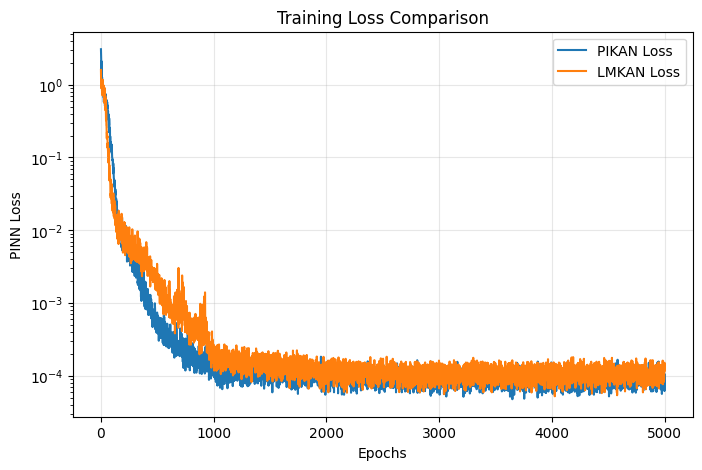

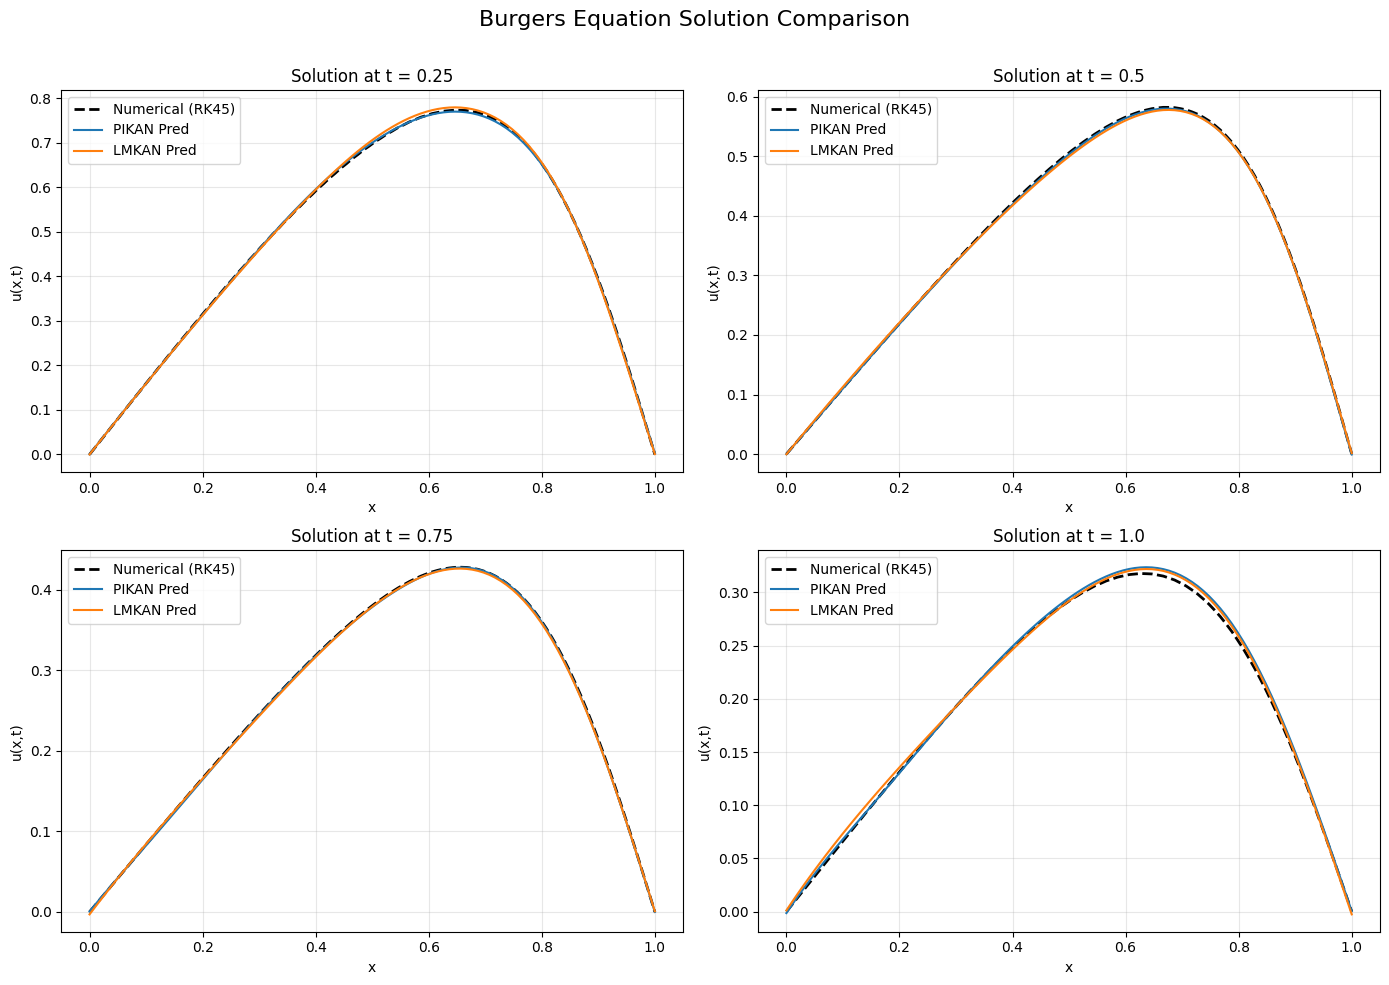

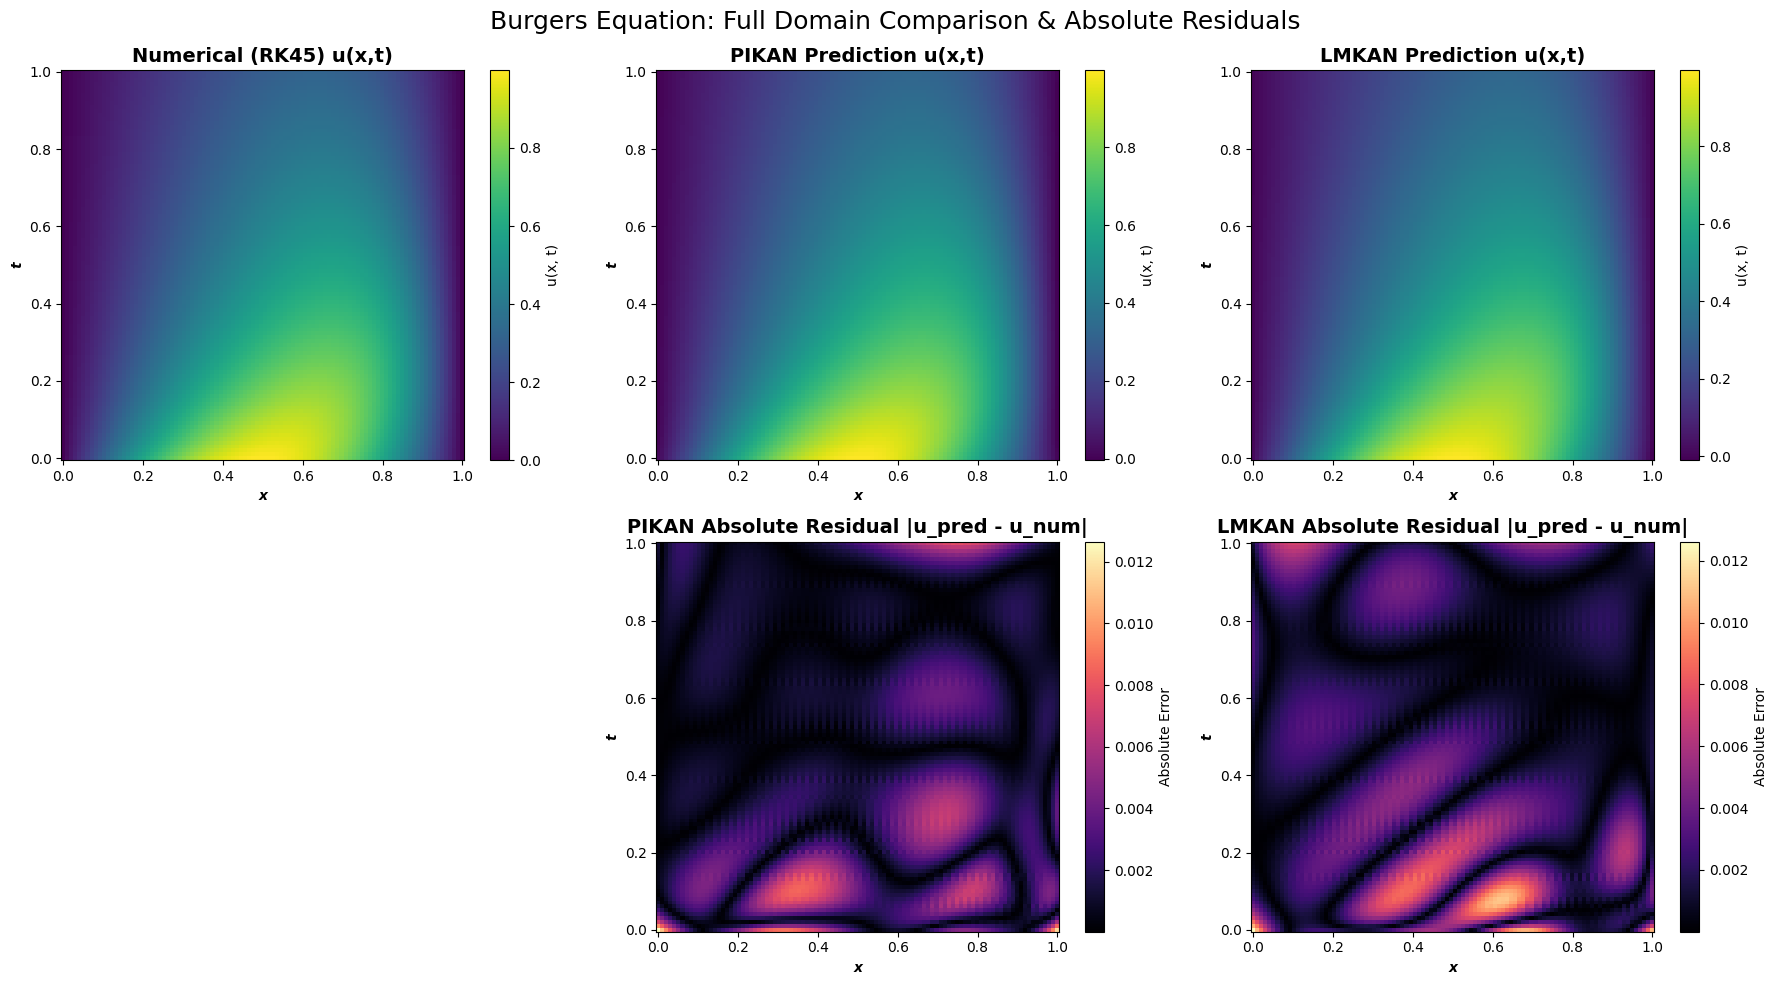

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib.colors import Normalize
import time
import os
import random

# ==========================================
# Set Fixed Random Seed for Reproducibility
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
set_seed(42)

# Import efficientkan and LMKAN
try:
    import efficientkan
    EFFICIENTKAN_AVAILABLE = True
except ImportError:
    print("Warning: efficientkan not found. PIKAN model will be skipped.")
    EFFICIENTKAN_AVAILABLE = False

try:
    import lm_kan
    LMKAN_AVAILABLE = True
except ImportError:
    print("Warning: lm_kan.py not found. Make sure it is in the same directory.")
    LMKAN_AVAILABLE = False

# ==========================================
# 1. Numerical Solution Setup
# ==========================================
print("Computing numerical solution...")
def burgers_rhs(t, u, dx, v):
    dudt = np.zeros_like(u)
    dudt[1:-1] = -u[1:-1] * (u[2:] - u[:-2]) / (2*dx) + v * (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    dudt[0] = 0  
    dudt[-1] = 0  
    return dudt

L = 1.0  
N_x = 100 
dx = L / (N_x - 1)  
v = 0.1 
x_np = np.linspace(0, L, N_x)
u0 = np.sin(np.pi * x_np)
t_span = (0, 1)
N_t = 100
t_eval = np.linspace(0, 1, N_t)  

solution = solve_ivp(burgers_rhs, t_span, u0, args=(dx, v), t_eval=t_eval, method='RK45')
print("Numerical solution computed.")

# ==========================================
# 2. Physics-Informed Training Setup
# ==========================================
# Time and space grids
x = torch.linspace(0, 1, N_x).view(-1, 1).requires_grad_(True)
t = torch.linspace(0.1, 1, N_t).view(-1, 1).requires_grad_(True)
x_ic = x.clone().detach().requires_grad_(True)
zeros = torch.zeros_like(t)
ones = torch.ones_like(t)

t_ic = torch.zeros_like(x_ic).requires_grad_(True)                        
u_ic = torch.sin(np.pi * x_ic)  

def get_pinn_loss(model, x, t, u_ic, model_type="efficient"):
    if model_type == "efficient":
        u_pred = model(x, t)
    else:
        u_pred = model(torch.cat([x, t], dim=1))
        
    t_sharp = np.linspace(0, 1, 100)
    num_points = int(len(t_sharp) * 0.1)
    # Note: drawing random points inside the loss step can create noisy loss curves 
    # but keeping it identical to the original implementation
    selected_points = np.random.choice(t_sharp, num_points, replace=False)
    
    u_t = torch.autograd.grad(u_pred, t, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_x = torch.autograd.grad(u_pred, x, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    
    f_pred = u_t - v*u_xx + u_pred*u_x 

    if model_type == "efficient":
        ic_pred = model(x_ic, t_ic)
        u_t0 = model(zeros, t)
        u_t1 = model(ones, t)
    else:
        ic_pred = model(torch.cat([x_ic, t_ic], dim=1))
        u_t0 = model(torch.cat([zeros, t], dim=1))
        u_t1 = model(torch.cat([ones, t], dim=1))

    ic_loss = torch.mean((ic_pred - u_ic)**2)
    
    loss_sharp = 0
    for t_val in selected_points:
        t_knot = t_val * ones
        if model_type == "efficient":
            u_sharp = model(x_ic, t_knot)
        else:
            u_sharp = model(torch.cat([x_ic, t_knot], dim=1))
            
        t_index = np.argmin(np.abs(t_eval - t_val))
        u_numerical_sharp = solution.y[:, t_index]
        u_numerical_sharp = torch.tensor(u_numerical_sharp, dtype=torch.float32).view(-1, 1).requires_grad_(True)
        loss_sharp += torch.mean((u_numerical_sharp - u_sharp) ** 2)
        
    L_boundary = torch.mean((u_t0 - zeros) ** 2 + (u_t1 - zeros) ** 2 + loss_sharp)
    loss = 1.5*torch.mean(f_pred**2) + L_boundary + 0.5*ic_loss
    return loss

def train_model(model, model_type, num_epochs=5000):
    optimizer = optim.AdamW(model.parameters(), lr=0.005)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.1)
    
    loss_list = []
    start_time = time.time()
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss = get_pinn_loss(model, x, t, u_ic, model_type=model_type)
        loss.backward(retain_graph=True) 
        optimizer.step()
        scheduler.step()
        
        loss_list.append(loss.item())
        if epoch % 500 == 0:
            print(f'[{model_type}] Epoch {epoch:4d}, Loss: {loss.item():.6f}')
            
    print(f'[{model_type}] Training finished in {time.time() - start_time:.2f}s, Final Loss: {loss_list[-1]:.6f}')
    return loss_list

# ==========================================
# 3. Model Initialization & Training
# ==========================================

# ----------------- Configurations -----------------
# PIKAN Config
PIKAN_LAYERS = [2, 8, 4, 1]

# LMKAN Config (Tuned for ~1117 params, exactly ~2x PIKAN's ~572 params)
LMKAN_WIDTH = 8
LMKAN_DEPTH = 2
LMKAN_K = 8 
LMKAN_METRIC_HIDDEN = 9
LMKAN_GAMMA = 2.5
LMKAN_BASIS = "rbf"  # More bases (K=8) and greater width sharply resolve the shock wave
# --------------------------------------------------

results = {}

if EFFICIENTKAN_AVAILABLE:
    print("\n--- Training PIKAN (efficientkan) ---")
    pikan_model = efficientkan.KAN_twovariable(PIKAN_LAYERS)
    pikan_loss = train_model(pikan_model, "efficient", num_epochs=5000)
    results['PIKAN'] = {'model': pikan_model, 'loss': pikan_loss, 'type': 'efficient'}

if LMKAN_AVAILABLE:
    print("\n--- Training LMKAN ---")
    lmkan_model = lm_kan.LMKAN(
        in_dim=2,
        width=LMKAN_WIDTH,
        depth=LMKAN_DEPTH,
        K=LMKAN_K,
        basis=LMKAN_BASIS,
        gamma=LMKAN_GAMMA,
        metric_hidden=LMKAN_METRIC_HIDDEN,
    )
    lmkan_loss = train_model(lmkan_model, "lmkan", num_epochs=5000)
    results['LMKAN'] = {'model': lmkan_model, 'loss': lmkan_loss, 'type': 'lmkan'}

# ==========================================
# 4. Evaluation & Visualization 
# ==========================================
if not results:
    print("No models were trained. Exiting.")
    exit(0)

OUTPUT_DIR = 'outputs_v3_1'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Print Model Parameters
print("\n--- Model Parameters ---")
for name, data in results.items():
    model = data['model']
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name} Trainable Parameters: {num_params:,}")

# Plot 1: Loss curves
plt.figure(figsize=(8, 5))
for name, data in results.items():
    plt.plot(data['loss'], label=f'{name} Loss')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('PINN Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/loss_comparison.pdf')
print(f"\nSaved loss comparison plot to {OUTPUT_DIR}/loss_comparison.pdf")

# Predict over a meshgrid for full solution surface (if needed) and specific timestamps
test_x = torch.linspace(0, 1, 100).view(-1, 1)

eval_t_points = [0.25, 0.50, 0.75, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Burgers Equation Solution Comparison', fontsize=16)

for i, t_val in enumerate(eval_t_points):
    ax = axes[i//2, i%2]
    
    # 1. Plot Numerical Solution
    t_idx = np.argmin(np.abs(t_eval - t_val))
    num_u = solution.y[:, t_idx]
    ax.plot(x_np, num_u, 'k--', linewidth=2, label='Numerical (RK45)')
    
    test_t = (torch.ones(100) * t_val).view(-1, 1)
    
    # 2. Plot Model Predictions
    with torch.no_grad():
        for name, data in results.items():
            model = data['model']
            m_type = data['type']
            
            if m_type == "efficient":
                pred_u = model(test_x, test_t).numpy().flatten()
            else:
                pred_u = model(torch.cat([test_x, test_t], dim=1)).numpy().flatten()
                
            ax.plot(x_np, pred_u, label=f'{name} Pred')
            
            # Save the predicted output to the outputs folder
            np.savetxt(f'{OUTPUT_DIR}/{name}_pred_t_{t_val}.txt', pred_u, header=f'Prediction for {name} at t={t_val}')
            
            # Print explicit absolute error at these timestamps
            err = np.mean(np.abs(pred_u - num_u))
            print(f"MAE at t={t_val}: {name} = {err:.5f}")
            
        # Also save the numerical solution for reference
        np.savetxt(f'{OUTPUT_DIR}/Numerical_t_{t_val}.txt', num_u, header=f'Numerical Solution at t={t_val}')

    ax.set_title(f'Solution at t = {t_val}')
    ax.set_xlabel('x')
    ax.set_ylabel('u(x,t)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig(f'{OUTPUT_DIR}/solution_comparison.pdf')
print(f"Saved solution comparison plot to {OUTPUT_DIR}/solution_comparison.pdf")

# ==========================================
# 5. Full Domain Heatmap Visualization (u(x,t) and Residuals)
# ==========================================
if len(results) > 0:
    print("\nGenerating full 2D domain heatmaps and residuals...")
    x_grid = np.linspace(0, 1, 100)
    t_grid = np.linspace(0, 1, 100)
    X, T = np.meshgrid(x_grid, t_grid)
    
    # Flatten for PINN evaluation
    X_flat = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1)
    T_flat = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1)
    
    # Numerical Solution (Shape: 100x100, where rows are t, cols are x)
    U_num = solution.y.T  
    
    num_models = len(results)
    # Row 1: u(x,t) plots, Row 2: |u_pred - u_num| residual plots
    fig2, axes2 = plt.subplots(2, num_models + 1, figsize=(6 * (num_models + 1), 10))
    fig2.suptitle('Burgers Equation: Full Domain Comparison & Absolute Residuals', fontsize=18)
    
    # 1. Plot Numerical Solution
    ax_num = axes2[0, 0]
    im_num = ax_num.pcolormesh(X, T, U_num, shading='auto', cmap='viridis')
    ax_num.set_title('Numerical (RK45) u(x,t)', fontsize=14, fontweight='bold')
    ax_num.set_xlabel('x', fontweight='bold', fontstyle='italic')
    ax_num.set_ylabel('t', fontweight='bold', fontstyle='italic')
    fig2.colorbar(im_num, ax=ax_num, label='u(x, t)')
    
    # Hide the subplot below numerical (no residual for ground truth)
    axes2[1, 0].axis('off')
    
    # 2. Iterate Models and Plot (Heatmap + Residual)
    col_idx = 1
    for name, data in results.items():
        model = data['model']
        m_type = data['type']
        
        # Evaluate model over full grid
        with torch.no_grad():
            if m_type == "efficient":
                pred_u_flat = model(X_flat, T_flat).numpy().flatten()
            else:
                pred_u_flat = model(torch.cat([X_flat, T_flat], dim=1)).numpy().flatten()
                
        U_pred = pred_u_flat.reshape(100, 100)
        Residual = np.abs(U_pred - U_num)
        
        # Plot Model Prediction Heatmap
        ax_pred = axes2[0, col_idx]
        im_pred = ax_pred.pcolormesh(X, T, U_pred, shading='auto', cmap='viridis')
        ax_pred.set_title(f'{name} Prediction u(x,t)', fontsize=14, fontweight='bold')
        ax_pred.set_xlabel('x', fontweight='bold', fontstyle='italic')
        ax_pred.set_ylabel('t', fontweight='bold', fontstyle='italic')
        fig2.colorbar(im_pred, ax=ax_pred, label='u(x, t)')
        
        # Plot Absolute Residual Heatmap
        ax_res = axes2[1, col_idx]
        im_res = ax_res.pcolormesh(X, T, Residual, shading='auto', cmap='magma')
        ax_res.set_title(f'{name} Absolute Residual |u_pred - u_num|', fontsize=14, fontweight='bold')
        ax_res.set_xlabel('x', fontweight='bold', fontstyle='italic')
        ax_res.set_ylabel('t', fontweight='bold', fontstyle='italic')
        fig2.colorbar(im_res, ax=ax_res, label='Absolute Error')
        
        col_idx += 1

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.savefig(f'{OUTPUT_DIR}/heatmap_residual_comparison.pdf')
    print(f"Saved full domain heatmap & residual comparison to {OUTPUT_DIR}/heatmap_residual_comparison.pdf")

print("\nFinished successfully!")
